# Statistical tests for Attack A

Cleaned version of the notebook. The repeated plotting and statistical-test code is grouped into helper functions so the analysis can be rerun with fewer cells.


In [1]:
import colorsys
from pathlib import Path

import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scikit_posthocs as sp
from matplotlib.legend_handler import HandlerBase
from matplotlib.patches import Rectangle
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
from scipy import stats
from scipy.stats import kruskal


In [2]:
DATA_PATH = Path('./data/Attack-A-Results.csv')

MODEL_ORDER = ['1V', '2V-IS', '2V-IL', '3V']
LOSS_NAMES = ['Clean', 'FGSM', 'BIM']

LOSS_COL_MAP = {
    'Clean': 'Clean_IM_Loss',
    'FGSM': 'FGSM_IM_Loss',
    'BIM': 'BIM_IM_Loss',
}

MODEL_LABEL_MAP = {
    '1V': '1 View',
    '2V-IS': '2 Views - IS',
    '2V-IL': '2 Views - IL',
    '3V': '3 Views',
}

MODEL_COLOR_MAP = {
    '1V': 'tab:blue',
    '2V-IS': 'tab:orange',
    '2V-IL': '#ffb066',
    '3V': 'tab:red',
}

ATTACK_COMBOS = [
    (True, True),      # Image + Sketch attack
    (True, False),     # Image attack only
    (False, True),     # Sketch attack only
]

ATTACK_COMBO_LABELS = {
    (True, True): 'Image + Sketch',
    (True, False): 'Image',
    (False, True): 'Sketch',
}

ATTACK_COMBO_SHADES = {
    (True, True): 0.75,
    (True, False): 1.00,
    (False, True): 1.30,
}


In [3]:
df = pd.read_csv(DATA_PATH)
df.head()


,model,image_attack,sketch_attack,Clean_IM_Loss,FGSM_IM_Loss,BIM_IM_Loss,Clean_SK_Loss,FGSM_SK_Loss,BIM_SK_Loss,Clean_LA_Loss,FGSM_LA_Loss,BIM_LA_Loss
0,3V,True,True,0.014524,0.239832,0.181438,0.059129,0.074593,0.066791,0.001540,0.038809,0.010188
1,3V,True,True,0.015393,0.220886,0.165209,0.059679,0.074099,0.066236,0.000997,0.015301,0.006461
2,3V,True,True,0.014677,0.224152,0.166810,0.056570,0.071467,0.063751,0.001310,0.043505,0.008856
3,3V,True,True,0.015958,0.242522,0.182911,0.057411,0.072124,0.064613,0.001788,0.037404,0.008774
4,3V,True,True,0.015271,0.240027,0.181095,0.058963,0.074115,0.066429,0.001093,0.029024,0.008979


## Helper functions


In [4]:
def mean_losses(data, attack_combos):
    """Return mean losses per model and attack-combination setting."""
    mask = False
    for image_attack, sketch_attack in attack_combos:
        mask |= (data['image_attack'].eq(image_attack) & data['sketch_attack'].eq(sketch_attack))

    return (
        data.loc[mask]
        .groupby(['model', 'image_attack', 'sketch_attack'], as_index=False)[list(LOSS_COL_MAP.values())]
        .mean()
    )


def adjust_color(color, amount=1.0):
    """Darken or lighten a color while preserving its hue."""
    color = mcolors.cnames.get(color, color)
    r, g, b = mcolors.to_rgb(color)
    h, l, s = colorsys.rgb_to_hls(r, g, b)
    l = np.clip(amount * l, 0, 1)
    return colorsys.hls_to_rgb(h, l, s)


class HandlerDoublePatch(HandlerBase):
    """Legend handler showing two color patches on one row."""

    def create_artists(self, legend, orig_handle, xdescent, ydescent, width, height, fontsize, trans):
        color1, color2 = orig_handle
        patch_width = width * 0.42
        gap = width * 0.08

        patches = [
            Rectangle(
                (xdescent, ydescent), patch_width, height,
                facecolor=color1, edgecolor='black', linewidth=0.6, transform=trans
            ),
            Rectangle(
                (xdescent + patch_width + gap, ydescent), patch_width, height,
                facecolor=color2, edgecolor='black', linewidth=0.6, transform=trans
            ),
        ]
        return patches


def add_group_labels(ax, group_centers, model_order):
    for center, model in zip(group_centers, model_order):
        ax.text(
            center, -0.14, MODEL_LABEL_MAP[model],
            ha='center', va='top', fontsize=14, fontweight='bold',
            transform=ax.get_xaxis_transform()
        )


def format_loss_axis(ax, x_positions, x_labels, group_centers, model_order, title):
    ax.set_xticks(x_positions)
    ax.set_xticklabels(x_labels, rotation=45, ha='right', fontsize=11)
    add_group_labels(ax, group_centers, model_order)

    ax.set_title(title, fontsize=20, fontweight='bold')
    ax.set_ylabel('Mean Image Loss', fontsize=16)
    ax.tick_params(axis='y', labelsize=14)
    ax.grid(axis='y', linestyle='--', alpha=0.7)


In [5]:
def plot_model_attack_losses(mean_df, model_order=MODEL_ORDER, title='Mean Image Loss per Model and Attack Type'):
    """Plot Clean, FGSM, and BIM losses for each model. Colors represent models/views."""
    mean_df = mean_df.set_index('model').loc[model_order].reset_index()
    attack_values = {loss: mean_df[LOSS_COL_MAP[loss]].to_numpy() for loss in LOSS_NAMES}

    bar_width = 0.22
    group_gap = 0.55
    x_positions, x_labels = [], []

    fig, ax = plt.subplots(figsize=(10, 6), dpi=300)

    for i, model in enumerate(model_order):
        group_start = i * (len(LOSS_NAMES) * bar_width + group_gap)

        for j, loss in enumerate(LOSS_NAMES):
            xpos = group_start + j * bar_width
            x_positions.append(xpos)
            x_labels.append(loss)

            ax.bar(
                xpos,
                attack_values[loss][i],
                width=bar_width,
                color=MODEL_COLOR_MAP[model],
                edgecolor='black',
                linewidth=0.6,
            )

    group_centers = [
        i * (len(LOSS_NAMES) * bar_width + group_gap) + (len(LOSS_NAMES) - 1) * bar_width / 2
        for i in range(len(model_order))
    ]

    format_loss_axis(ax, x_positions, x_labels, group_centers, model_order, title)
    plt.tight_layout()
    plt.show()


In [6]:
def plot_attack_combo_losses(
    plot_df,
    model_order=MODEL_ORDER,
    title='Mean Image Loss per Model and Attack Type',
    add_inset=True,
):
    """Plot overlapping bars for image, sketch, and image+sketch attack settings."""
    lookup = {
        (row['model'], row['image_attack'], row['sketch_attack']): row
        for _, row in plot_df.iterrows()
    }

    bar_width = 0.22
    group_gap = 0.55
    widths = {(True, True): 0.24, (True, False): 0.17, (False, True): 0.10}

    x_positions, x_pairs = [], []
    for i, model in enumerate(model_order):
        group_start = i * (len(LOSS_NAMES) * bar_width + group_gap)
        for j, loss in enumerate(LOSS_NAMES):
            x_positions.append(group_start + j * bar_width)
            x_pairs.append((model, loss))

    fig, ax = plt.subplots(figsize=(10, 6), dpi=300)
    combo_heights, combo_colors = {}, {}

    for i, combo in enumerate(ATTACK_COMBOS):
        heights = []
        colors = []

        for model, loss_name in x_pairs:
            row = lookup.get((model, *combo))
            heights.append(np.nan if row is None else row[LOSS_COL_MAP[loss_name]])
            colors.append(adjust_color(MODEL_COLOR_MAP[model], ATTACK_COMBO_SHADES[combo]))

        combo_heights[combo] = heights
        combo_colors[combo] = colors

        ax.bar(
            x_positions,
            heights,
            width=widths[combo],
            color=colors,
            edgecolor='black',
            linewidth=0.6,
            zorder=3 + i,
        )

    group_centers = [
        i * (len(LOSS_NAMES) * bar_width + group_gap) + (len(LOSS_NAMES) - 1) * bar_width / 2
        for i in range(len(model_order))
    ]

    all_vals = np.ravel([combo_heights[combo] for combo in ATTACK_COMBOS])
    ax.set_ylim(0, np.nanmax(all_vals) * 1.12)

    format_loss_axis(
        ax,
        x_positions,
        [loss for _, loss in x_pairs],
        group_centers,
        model_order,
        title,
    )

    legend_handles = [
        (
            adjust_color(MODEL_COLOR_MAP['2V-IS'], ATTACK_COMBO_SHADES[combo]),
            adjust_color(MODEL_COLOR_MAP['3V'], ATTACK_COMBO_SHADES[combo]),
        )
        for combo in ATTACK_COMBOS
    ]

    ax.legend(
        legend_handles,
        [ATTACK_COMBO_LABELS[combo] for combo in ATTACK_COMBOS],
        handler_map={tuple: HandlerDoublePatch()},
        title='Attack combination',
        loc='upper left',
        fontsize=11,
        title_fontsize=12,
    )

    if add_inset:
        add_fgsm_inset(ax, x_positions, combo_heights, combo_colors, widths, model_order)

    plt.tight_layout()
    plt.show()


def add_fgsm_inset(ax, x_positions, combo_heights, combo_colors, widths, model_order):
    """Zoom in on the 2V-IS FGSM bar."""
    axins = inset_axes(ax, width='20%', height='22%', loc='upper center', borderpad=1.0)

    for i, combo in enumerate(ATTACK_COMBOS):
        axins.bar(
            x_positions,
            combo_heights[combo],
            width=widths[combo],
            color=combo_colors[combo],
            edgecolor='black',
            linewidth=0.6,
            zorder=3 + i,
        )

    fgsm_idx = model_order.index('2V-IS') * len(LOSS_NAMES) + LOSS_NAMES.index('FGSM')
    x_fgsm = x_positions[fgsm_idx]

    vals_fgsm = [combo_heights[combo][fgsm_idx] for combo in [(True, True), (True, False)]]
    vals_fgsm = [v for v in vals_fgsm if not np.isnan(v)]

    axins.set_xlim(x_fgsm - 0.22, x_fgsm + 0.22)
    axins.set_ylim(min(vals_fgsm) * 0.98, max(vals_fgsm) * 1.01)
    axins.set_xticks([x_fgsm])
    axins.set_xticklabels(['FGSM'], fontsize=9)
    axins.tick_params(axis='y', labelsize=9)
    axins.grid(axis='y', linestyle='--', alpha=0.35)

    mark_inset(ax, axins, loc1=3, loc2=4, fc='none', ec='0.4', lw=1)


## Mean loss plots


In [7]:
mean_clean_loss = mean_losses(df, attack_combos=[(True, False)])
mean_clean_loss


,model,image_attack,sketch_attack,Clean_IM_Loss,FGSM_IM_Loss,BIM_IM_Loss
0,1V,True,False,0.011886,0.126960,0.073916
1,2V-IL,True,False,0.014399,0.158764,0.099357
2,2V-IS,True,False,0.015343,0.177584,0.116842
3,3V,True,False,0.015168,0.237791,0.179206


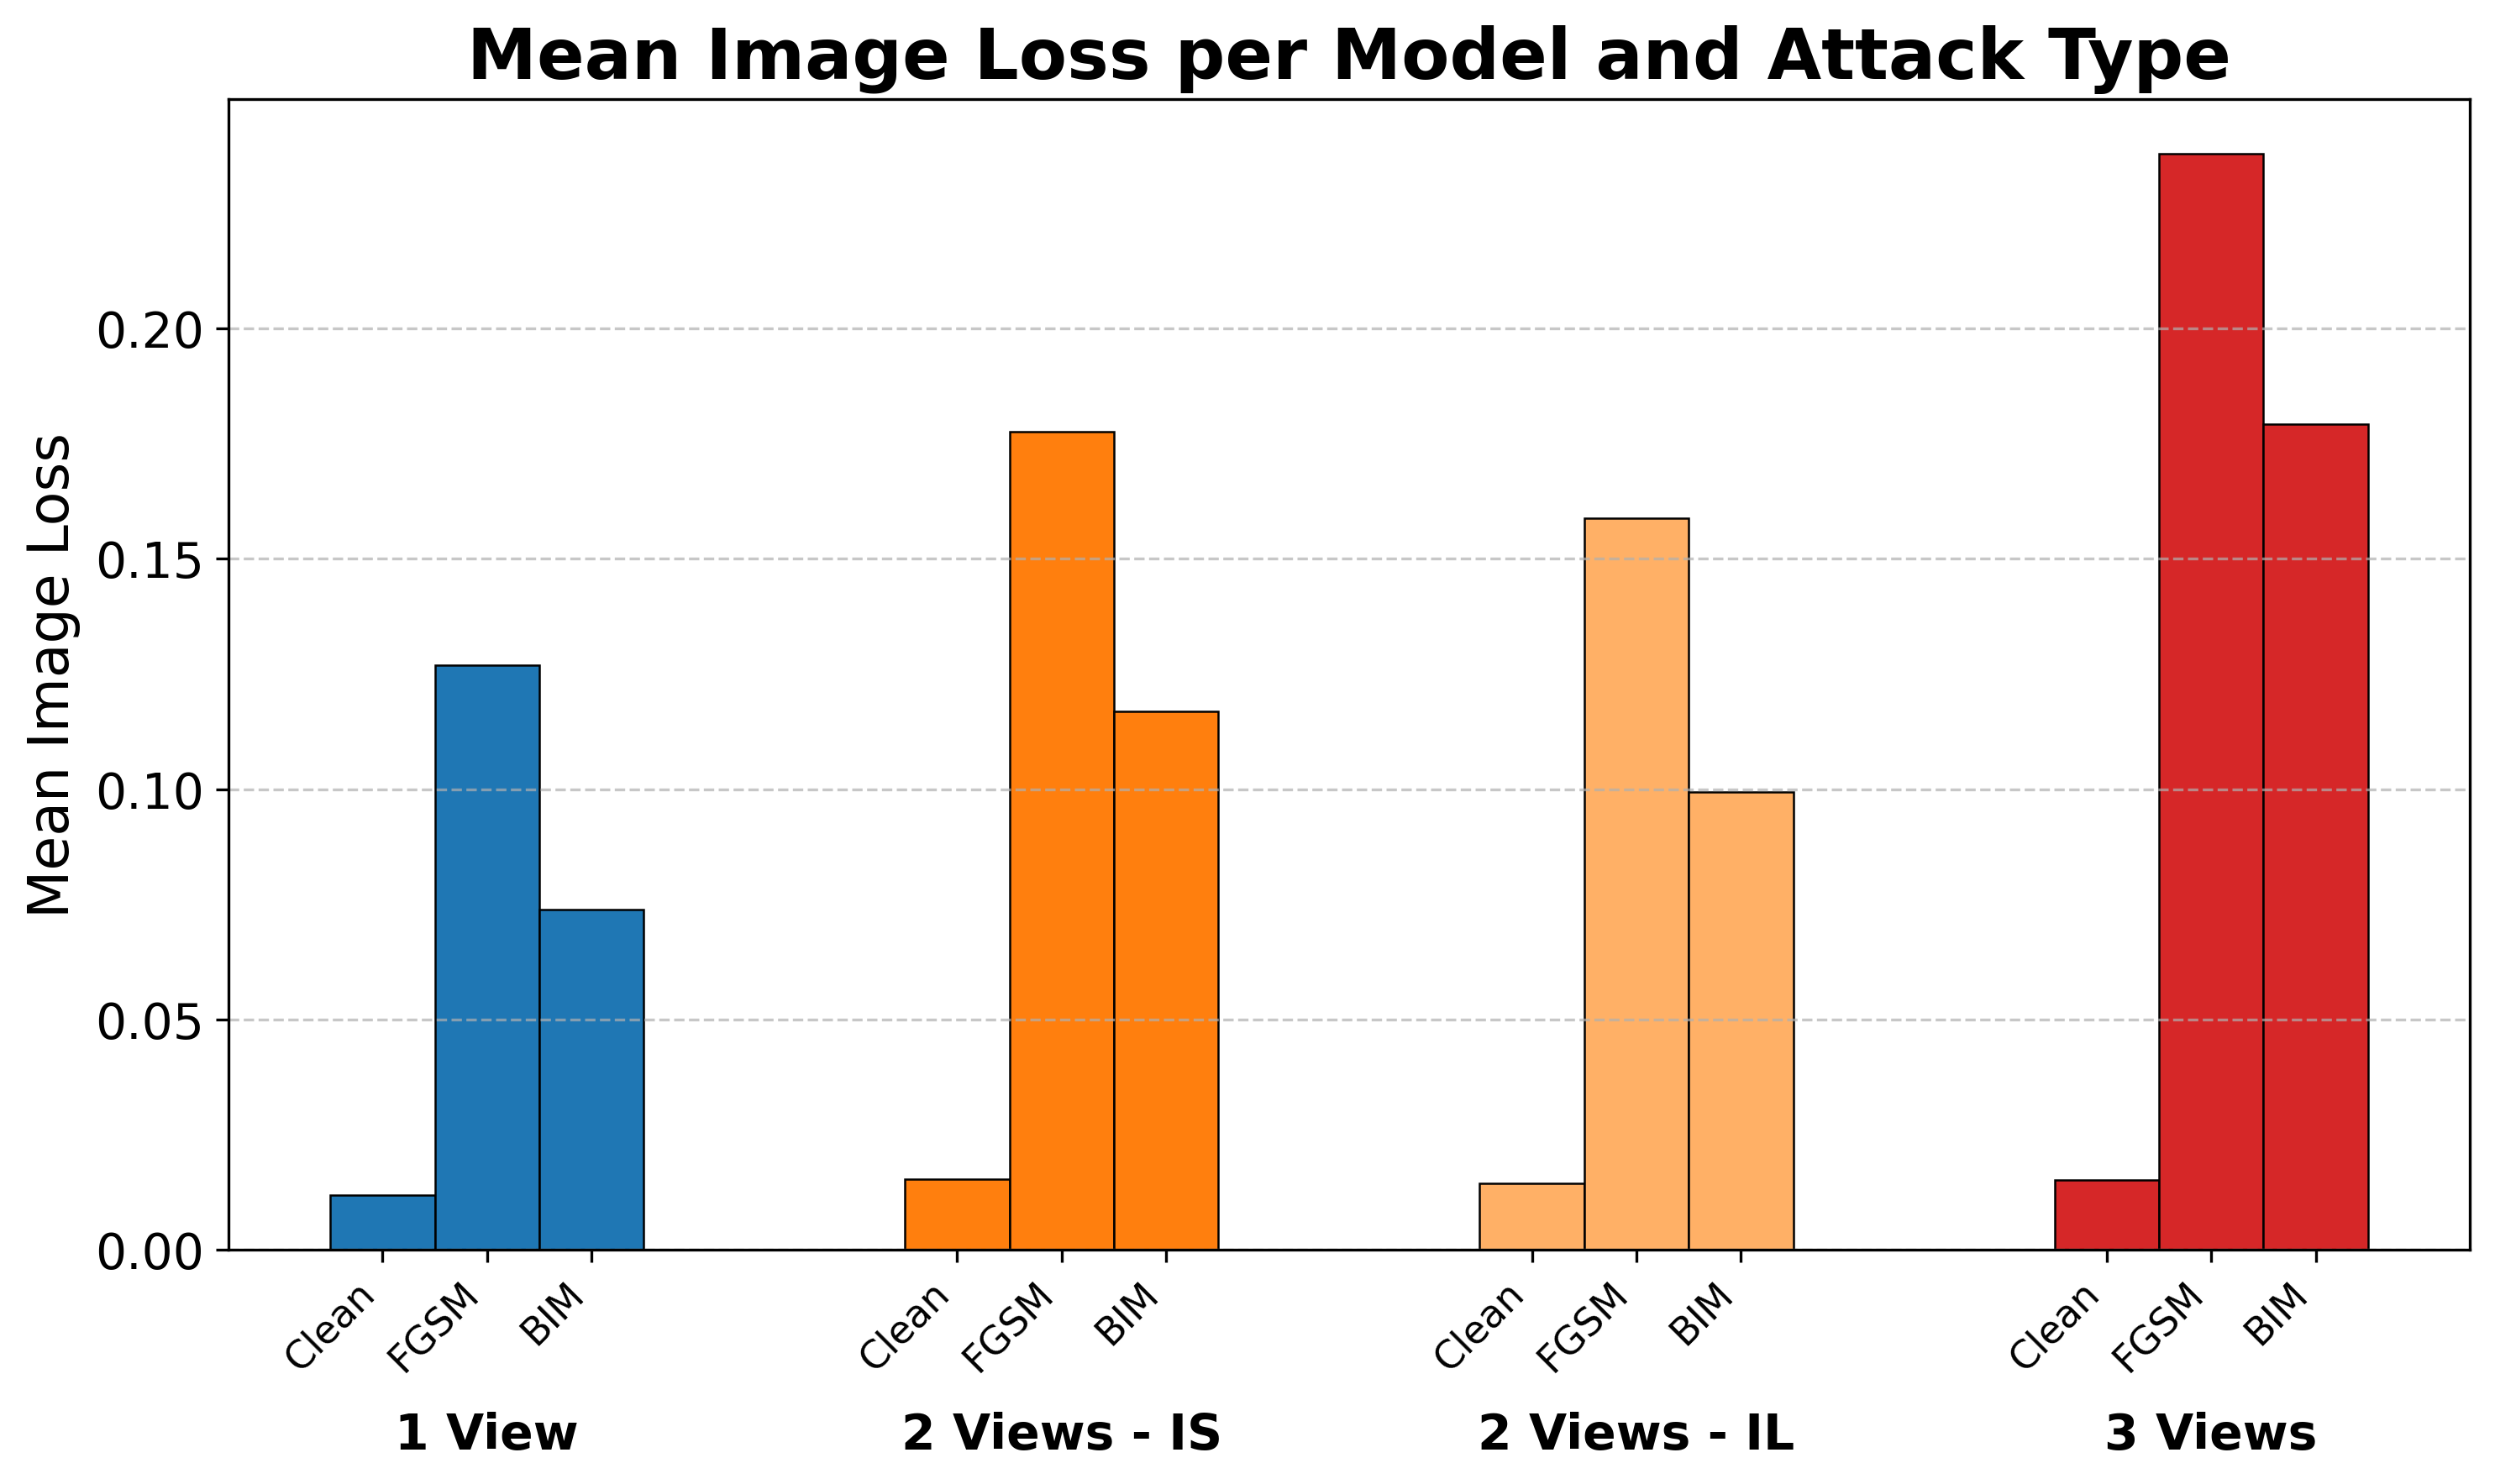

In [8]:
plot_model_attack_losses(mean_clean_loss)

/var/folders/yd/xmg755ln3fscr3pf2_0xpclm0000gn/T/ipykernel_97307/1130542055.py:87: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


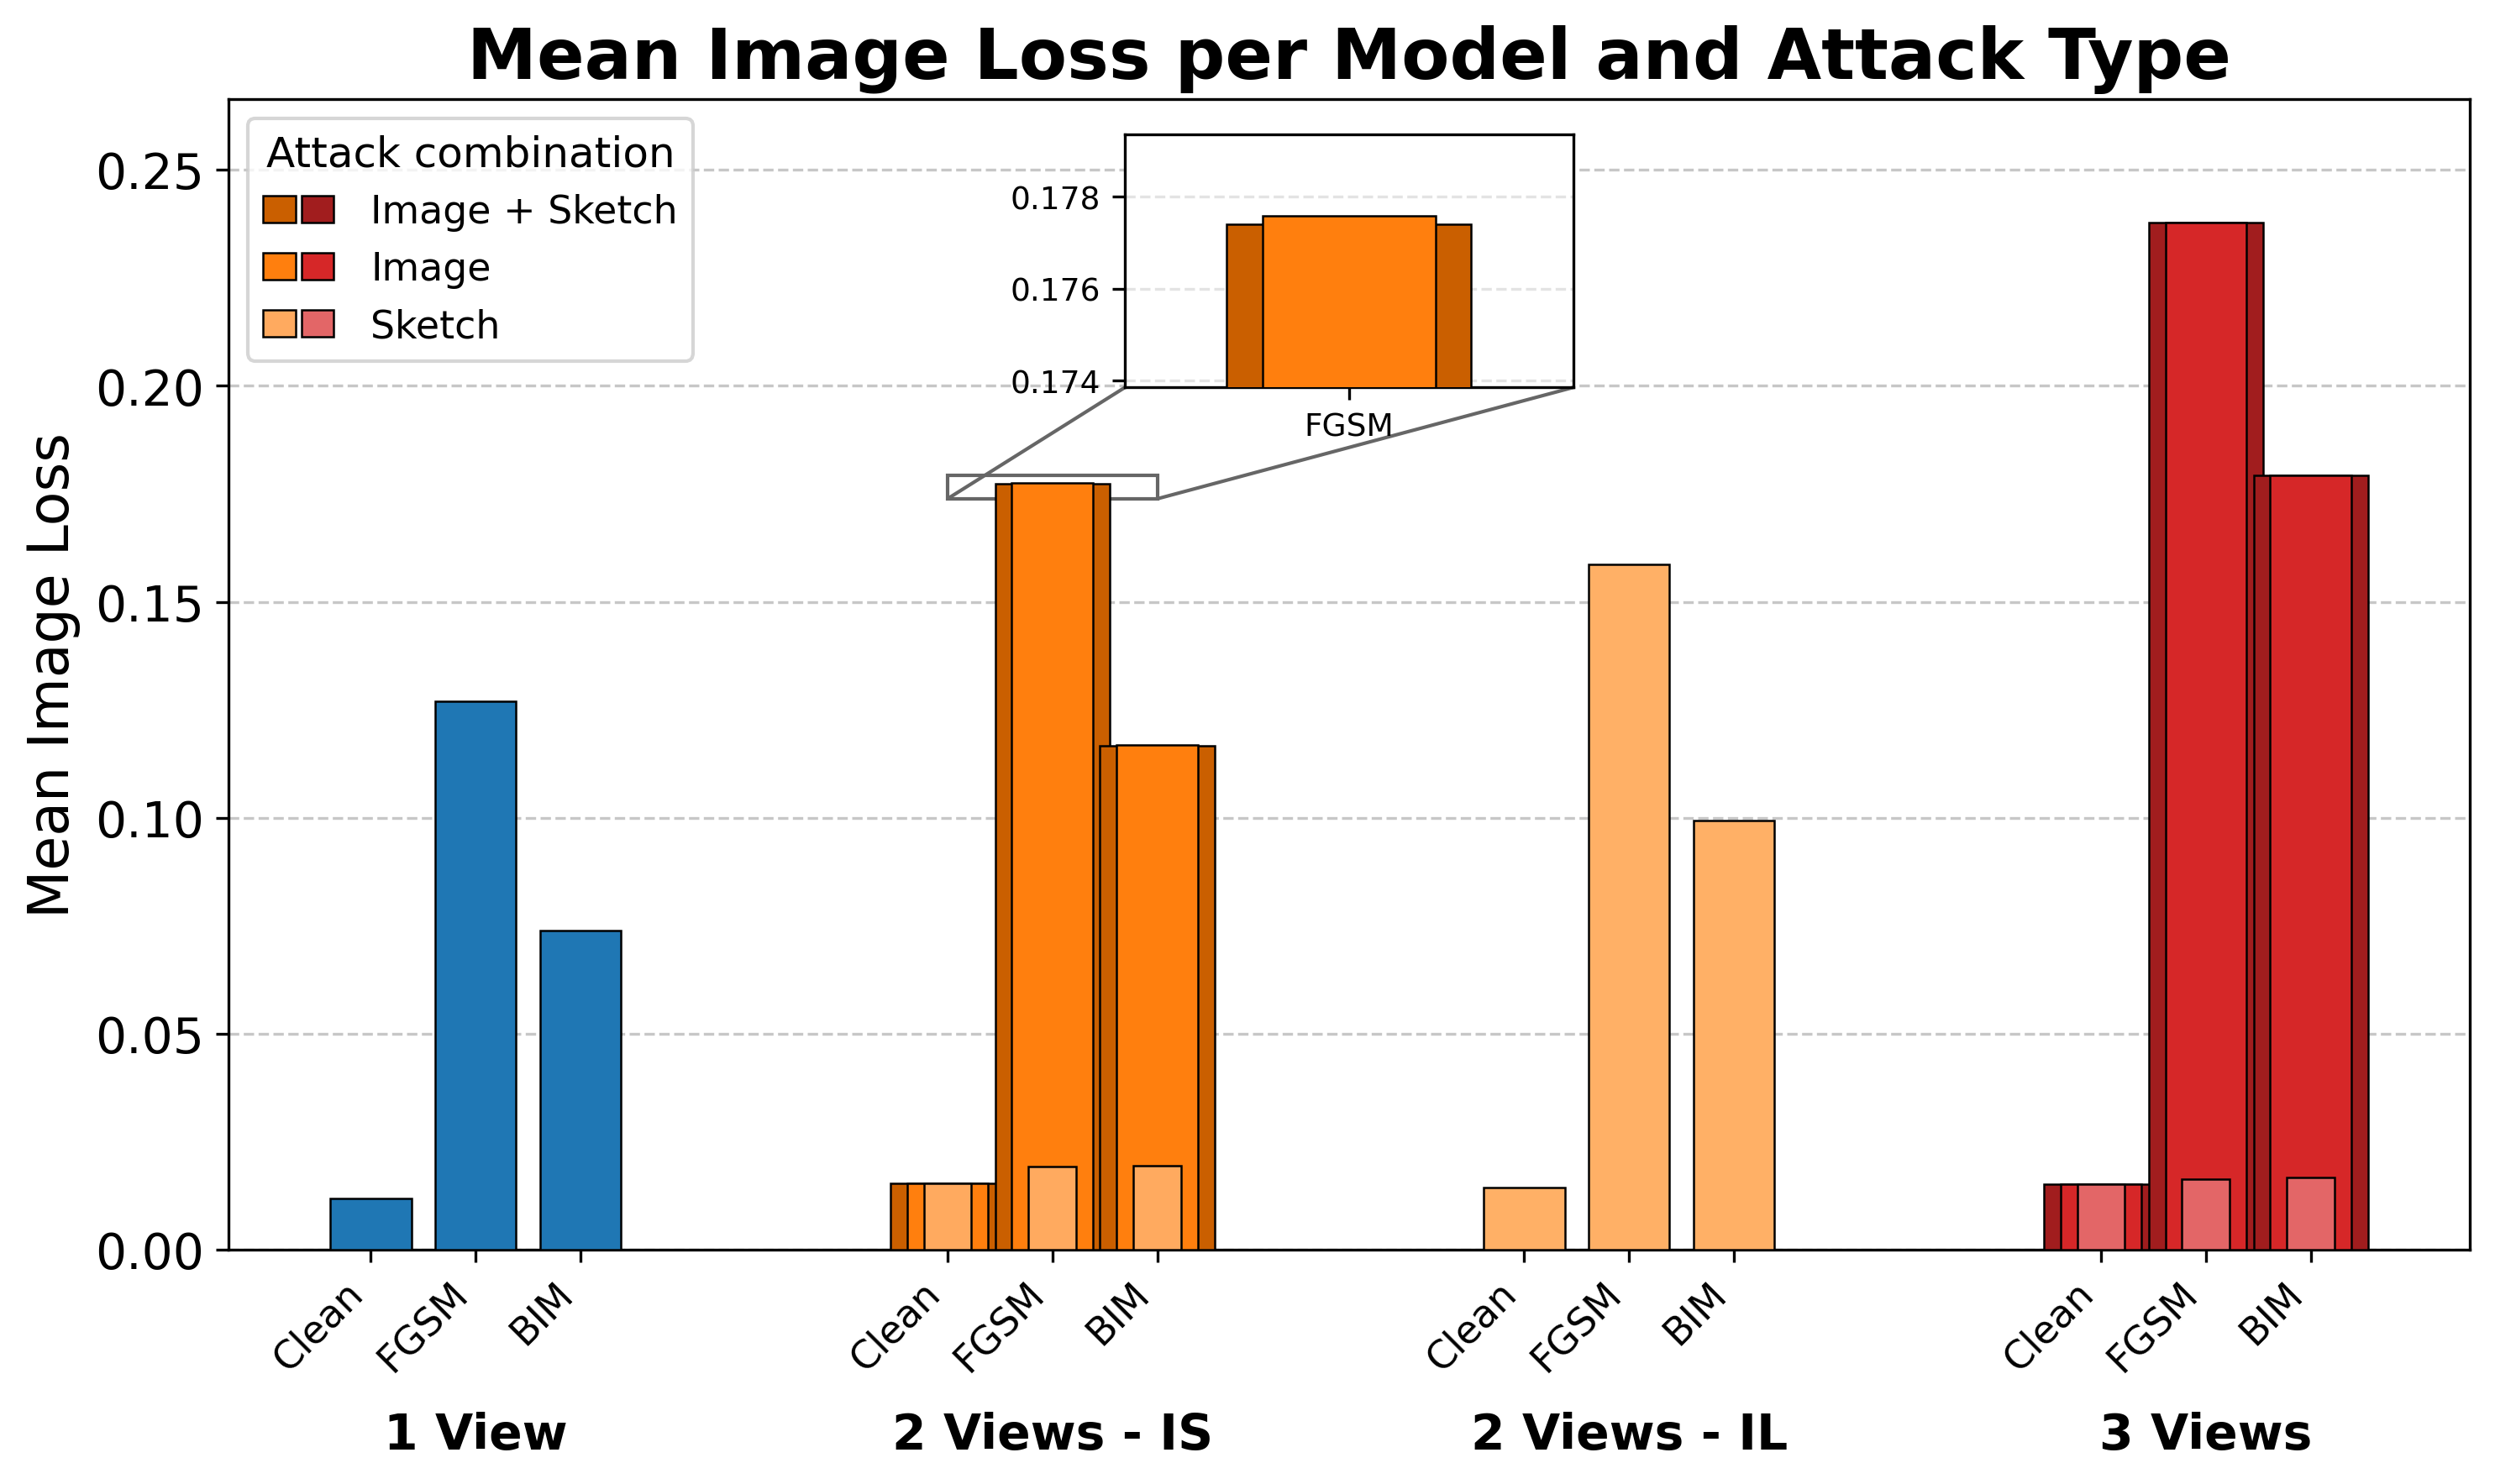

In [9]:
plot_df = mean_losses(df, attack_combos=ATTACK_COMBOS)
plot_attack_combo_losses(plot_df, add_inset=True)

## Statistical tests


In [10]:
def select_attack_setting(data, image_attack=True, sketch_attack=False, models=MODEL_ORDER):
    return data.loc[
        data['model'].isin(models)
        & data['image_attack'].eq(image_attack)
        & data['sketch_attack'].eq(sketch_attack)
    ].copy()


def kruskal_dunn_by_model(data, value_col, group_col='model', p_adjust='holm', show_plot=True):
    """Run Kruskal-Wallis followed by Dunn post-hoc test."""
    groups = [
        data.loc[data[group_col].eq(model), value_col].dropna().to_numpy()
        for model in MODEL_ORDER
    ]

    h_stat, p_value = kruskal(*groups)
    print(f'{value_col}')
    print(f'H-statistic: {h_stat:.6f}')
    print(f'P-value: {p_value:.6e}\n')

    dunn_results = sp.posthoc_dunn(
        data,
        val_col=value_col,
        group_col=group_col,
        p_adjust=p_adjust,
    )

    if show_plot:
        heatmap_args = {
            'linewidths': 0.25,
            'linecolor': '0.5',
            'clip_on': False,
            'square': True,
            'cbar_ax_bbox': [0.80, 0.35, 0.04, 0.3],
        }
        sp.sign_plot(dunn_results, **heatmap_args)
        plt.show()

    print(sp.compact_letter_display(dunn_results))
    return h_stat, p_value, dunn_results


In [11]:
df_stat_test = select_attack_setting(df, image_attack=True, sketch_attack=False)
print(df_stat_test.groupby('model').size())


model
1V       10
2V-IL    10
2V-IS    10
3V       10
dtype: int64


Clean_IM_Loss
H-statistic: 26.499512
P-value: 7.495682e-06



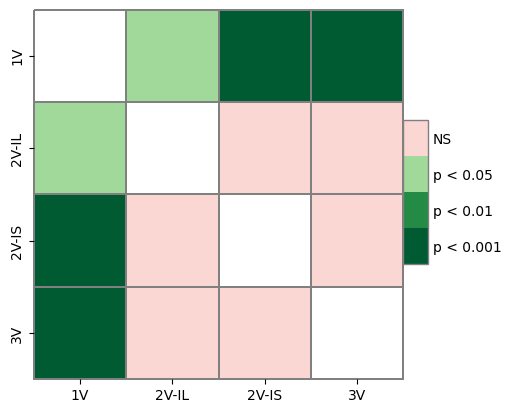

1V       a 
2V-IL     b
2V-IS     b
3V        b
Name: letters, dtype: object

------------------------------------------------------------

FGSM_IM_Loss
H-statistic: 36.023415
P-value: 7.403502e-08



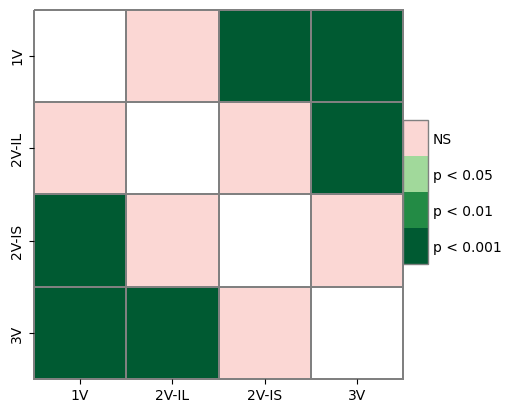

1V       a  
2V-IL    ab 
2V-IS     bc
3V         c
Name: letters, dtype: object

------------------------------------------------------------

BIM_IM_Loss
H-statistic: 36.585366
P-value: 5.631199e-08



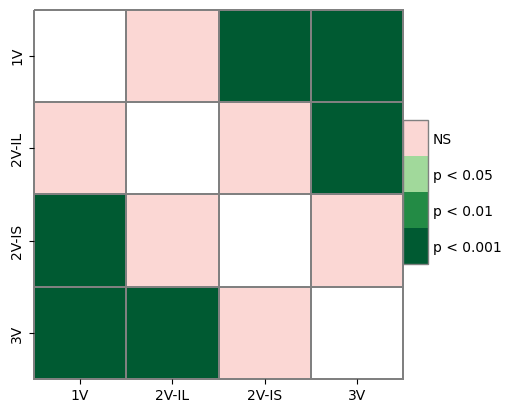

1V       a  
2V-IL    ab 
2V-IS     bc
3V         c
Name: letters, dtype: object

------------------------------------------------------------



In [12]:
for loss_col in LOSS_COL_MAP.values():
    kruskal_dunn_by_model(df_stat_test, loss_col)
    print('\n' + '-' * 60 + '\n')


## Paired comparisons: Image + Sketch vs. Image-only


In [13]:
def paired_attack_comparison(data, model, value_col='FGSM_IM_Loss'):
    grouped = (
        data.loc[data['model'].eq(model) & data['image_attack']]
        .groupby('sketch_attack')[value_col]
        .apply(list)
    )

    t_stat, p_value = stats.ttest_rel(grouped.loc[True], grouped.loc[False])
    print(f'{model} — {value_col}')
    print(f'T-statistic: {t_stat:.6f}')
    print(f'P-value: {p_value:.6e}\n')
    return t_stat, p_value


df_paired = df.loc[df['model'].isin(MODEL_ORDER) & df['image_attack']].copy()

for model in ['3V', '2V-IS']:
    paired_attack_comparison(df_paired, model, value_col='FGSM_IM_Loss')


3V — FGSM_IM_Loss
T-statistic: -1.519521
P-value: 1.629507e-01

2V-IS — FGSM_IM_Loss
T-statistic: -2.375577
P-value: 4.152765e-02

